# Numerical Derivatives Using NumPy

How to compute derivatives **numerically** — no symbolic math needed. This is the approach used in machine learning (gradient descent) and scientific computing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## The Idea

The derivative is defined as:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Instead of taking the limit, we pick a **small** $h$ and compute the ratio directly. There are three ways:

| Method | Formula | Accuracy |
|--------|---------|----------|
| **Forward** | $\frac{f(x+h) - f(x)}{h}$ | O(h) |
| **Backward** | $\frac{f(x) - f(x-h)}{h}$ | O(h) |
| **Central** | $\frac{f(x+h) - f(x-h)}{2h}$ | O(h²) — best! |

Central difference is the most accurate because errors from both sides cancel out.

## Implementing the Three Methods

In [2]:
def forward_difference(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

def backward_difference(f, x, h=1e-5):
    return (f(x) - f(x - h)) / h

def central_difference(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

## Example 1: $f(x) = x^2$

We know $f'(x) = 2x$, so $f'(3) = 6$. Let's see how close each method gets.

In [3]:
def f(x):
    return x**2

x = 3.0
exact = 2 * x  # f'(x) = 2x

for h in [1e-3, 1e-5, 1e-7, 1e-9]:
    fwd = forward_difference(f, x, h)
    bwd = backward_difference(f, x, h)
    ctr = central_difference(f, x, h)
    print(f"h={h:.0e}:  forward={fwd:.10f}  backward={bwd:.10f}  central={ctr:.10f}  (exact={exact})")

h=1e-03:  forward=6.0010000000  backward=5.9990000000  central=6.0000000000  (exact=6.0)
h=1e-05:  forward=6.0000100000  backward=5.9999900001  central=6.0000000000  (exact=6.0)
h=1e-07:  forward=6.0000000879  backward=5.9999998925  central=5.9999999902  (exact=6.0)
h=1e-09:  forward=6.0000004964  backward=6.0000004964  central=6.0000004964  (exact=6.0)


## Example 2: $f(x) = \sin(x)$

We know $f'(x) = \cos(x)$. Let's test at $x = \pi/4$.

In [4]:
x = np.pi / 4
exact = np.cos(x)

for h in [1e-3, 1e-5, 1e-7, 1e-9]:
    fwd = forward_difference(np.sin, x, h)
    bwd = backward_difference(np.sin, x, h)
    ctr = central_difference(np.sin, x, h)
    print(f"h={h:.0e}:  forward={fwd:.10f}  backward={bwd:.10f}  central={ctr:.10f}  (exact={exact:.10f})")

h=1e-03:  forward=0.7067531100  backward=0.7074602167  central=0.7071066633  (exact=0.7071067812)
h=1e-05:  forward=0.7071032456  backward=0.7071103167  central=0.7071067812  (exact=0.7071067812)
h=1e-07:  forward=0.7071067454  backward=0.7071068153  central=0.7071067804  (exact=0.7071067812)
h=1e-09:  forward=0.7071068175  backward=0.7071067065  central=0.7071067620  (exact=0.7071067812)


## How Step Size Affects Accuracy

Too large $h$ → bad approximation. Too small $h$ → floating-point errors dominate. Let's see this with $f(x) = e^x$ at $x = 1$.

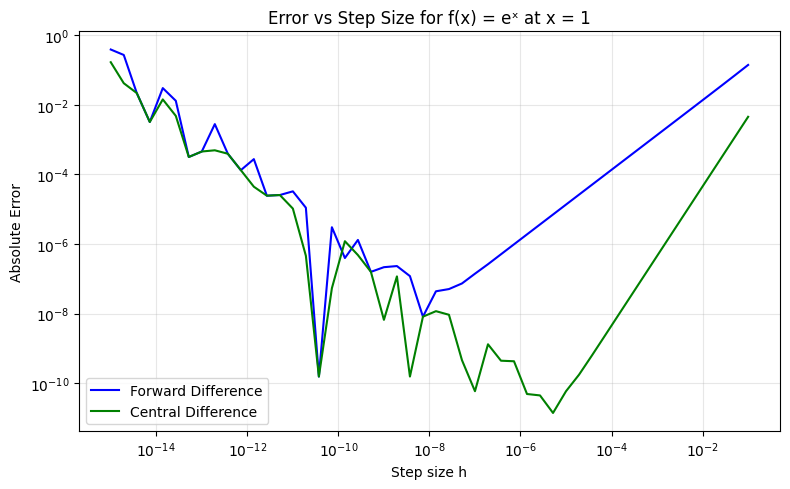

Notice: central difference reaches a lower error, but both blow up at very small h due to floating-point limits.
Sweet spot is around h = 1e-5 to 1e-8.


In [5]:
exact = np.e  # f'(1) = e^1

h_values = np.logspace(-15, -1, 50)
errors_fwd = [abs(forward_difference(np.exp, 1.0, h) - exact) for h in h_values]
errors_ctr = [abs(central_difference(np.exp, 1.0, h) - exact) for h in h_values]

plt.figure(figsize=(8, 5))
plt.loglog(h_values, errors_fwd, 'b-', label='Forward Difference')
plt.loglog(h_values, errors_ctr, 'g-', label='Central Difference')
plt.xlabel('Step size h')
plt.ylabel('Absolute Error')
plt.title('Error vs Step Size for f(x) = eˣ at x = 1')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("Notice: central difference reaches a lower error, but both blow up at very small h due to floating-point limits.")
print("Sweet spot is around h = 1e-5 to 1e-8.")

## NumPy's Built-in: `np.gradient()`

When you have an **array** of function values (not a formula), `np.gradient()` computes the derivative using central differences at interior points and forward/backward at the edges.

```python
dy_dx = np.gradient(y, x)
```

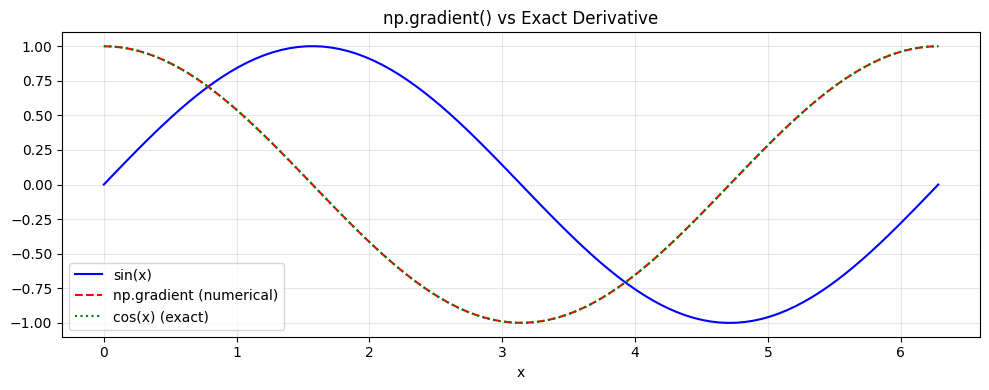

Max error: 6.71e-04


In [6]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

# Numerical derivative via np.gradient
dy_dx = np.gradient(y, x)

# Analytical derivative for comparison
dy_dx_exact = np.cos(x)

plt.figure(figsize=(10, 4))
plt.plot(x, y, 'b-', label='sin(x)')
plt.plot(x, dy_dx, 'r--', label="np.gradient (numerical)")
plt.plot(x, dy_dx_exact, 'g:', label="cos(x) (exact)")
plt.xlabel('x')
plt.legend()
plt.title('np.gradient() vs Exact Derivative')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max error: {np.max(np.abs(dy_dx - dy_dx_exact)):.2e}")

## Key Takeaways

- **Numerical derivatives** approximate $f'(x)$ using small perturbations — no algebra needed
- **Central difference** is the most accurate of the three methods (O(h²) vs O(h))
- Step size matters: **h ≈ 1e-5 to 1e-8** is the practical sweet spot
- `np.gradient()` computes derivatives over arrays using central differences
- This is the foundation of **gradient descent** in machine learning